# Assignment-6

This notebook contains the questions to test the proficiency in `Statistics`.

### Date: 1st February, 2026

### Steps to solve and upload the assignment 

- Download the notebook in your local machine.
- Solve the questions in the notebook and save it.
- Rename the file as `Assignment-06-<your_name>_<your_surname>.ipynb`. For example if your name is Dipika Chopra then name the file as `Assignment-06-Dipika_Chopra.ipynb`.
- For numerical problems you can either solve the same using using python in the solution notebook or you can solve it on paper and upload the scan pdf copy of the solution. 
- If you are solving it on paper then name the pdf file of the scan copy of the solution as `Assignment-06-<your_name>_<your_surname>.pdf`. For example if your name is Akash Kumar then name the file as `Assignment-06-Akash_Kumar.pdf`.
- Upload the solved notebook in your github repo under the folder **Assignment-6**.
- Upload the solved notebook and the scanned pdf copy of the solutions in the google drive location: https://drive.google.com/drive/folders/1YcMNgD9h_Kdh7-Q0no3xONNctBtzqcOJ?usp=sharing 
<h3><span style="color:red"> Deadline: 22nd February, 2026 </span></h3>

<h5><span style="color:blue"> <b>Instructions:</b> Please answer all the questions. For problems requiring numerical solutions, you are encouraged to write code in Python to compute the results. Show your steps and explain your reasoning. </span></h5>

### Problem-1

A startup company with 20 employees recorded their annual salaries (in INR Lakhs):
`[6.5, 7.2, 8.0, 6.8, 9.5, 7.0, 15.0, 7.5, 8.2, 6.9, 7.8, 10.5, 7.1, 8.5, 6.7, 7.3, 7.9, 9.0, 8.8, 7.6]`

(a) Calculate the mean, median, and mode of the salaries.

(b) Determine the range, variance, and standard deviation of the salaries.

(c) Calculate the Interquartile Range (IQR). What does the IQR tell you about the salary distribution?

(d) Construct a box plot for the salaries. Identify any potential outliers.


Mean:  8.19
Median:  7.699999999999999
Mode:  6.5
Data Range:  8.5
Variance:  3.6156842105263163
Standard Deviation:  1.9014952565090233
Q1: 7.074999999999999
Q3: 8.575
IQR:  1.5
Lower Dense:  4.824999999999999
Higher Dense:  10.825
Outliers:  [15.0]


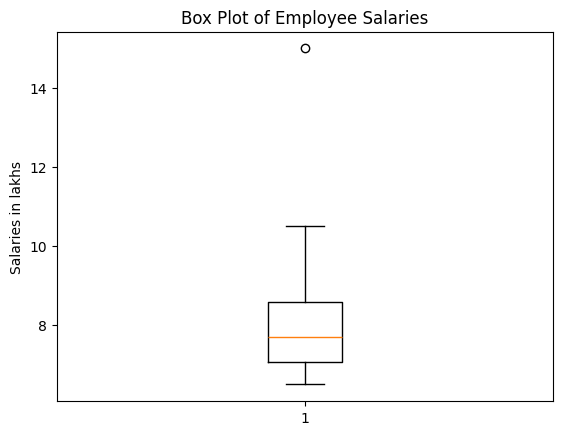

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from statistics import mean, median,mode

salaries = [6.5, 7.2, 8.0, 6.8, 9.5, 7.0, 15.0, 7.5, 8.2, 6.9,
            7.8, 10.5, 7.1, 8.5, 6.7, 7.3, 7.9, 9.0, 8.8, 7.6]

print("Mean: ",mean(salaries))
print("Median: ",median(salaries))
try:
    print("Mode: ",mode(salaries))
except StatisticsError:
    print("Mode: No unique mode")

# ----------------------------
# (b) Range, Variance, Standard Deviation
# -----------------------------

Range = max(salaries) - min(salaries)
variance = np.var(salaries,ddof=1)
standard_deviation = np.std(salaries,ddof=1)
print("Data Range: ",Range)
print("Variance: ",variance)
print("Standard Deviation: ",standard_deviation)

# ---------------------------
# InterQuartile Range
# ------------------------------


# internally what happens 25% * (20 - 1) = 4 .75   => which is between 4 and 5 index (7.0 + 7.1) / 2 = 7.07
Q1 = np.percentile(salaries,25) 
print("Q1:",Q1)
Q3 = np.percentile(salaries,75)
print("Q3:",Q3)
IQR = Q3 - Q1
print("IQR: ",IQR)

# ---------------------------
# Outlier Detection
# ----------------------------

lower_dense = Q1 - 1.5 * IQR
upper_dense = Q3 + 1.5 * IQR

outlier = [x for x in salaries if x < lower_dense or x > upper_dense]

print("Lower Dense: ", lower_dense)
print("Higher Dense: ", upper_dense)
print("Outliers: ", outlier)

# ---------------------------
# Box Plot
# ---------------------------

plt.boxplot(salaries)
plt.title("Box Plot of Employee Salaries")
plt.ylabel("Salaries in lakhs")
plt.show()


### Problem-2

A tech company conducted a customer satisfaction survey, rating their latest product on a scale of 1 to 10 (10 being highly satisfied). The scores from 30 randomly selected customers are:
[7, 8, 9, 6, 7, 8, 10, 5, 7, 8, 9, 7, 6, 8, 7, 9, 10, 6, 7, 8, 5, 9, 8, 7, 6, 7, 8, 9, 7, 8]

(a) Create a frequency distribution table for these scores.

(b) Plot a histogram of the customer satisfaction scores. Describe the shape of the distribution (e.g., symmetric, skewed).

(c) Calculate the Pearson's (first and second) coefficients of skewness for this data. Interpret the values.

(d) Calculate the excess kurtosis for this data using sample kurtosis formula. What does the kurtosis value suggest about the tails of the distribution?

In [13]:
# (A) Understanding User behaviour before modeling

import pandas as pd

scores = [7, 8, 9, 6, 7, 8, 10, 5, 7, 8, 9, 7, 6, 8, 7, 9, 10, 6, 7, 8, 5, 9, 8, 7, 6, 7, 8, 9, 7, 8]

pd.Series(scores)

# Frequency Distribution use cases in real world can be movie reviews analysis, movie recommendation systems.
freq_table = pd.Series(scores).value_counts().sort_index()

# Relative Frequency

relative_frequency = freq_table / len(scores)

result = pd.DataFrame({
    'Frequency': freq_table,
    'Relative_frequency': relative_frequency
})

print(result)
print("We can understand that most of the rating 7 & 8. Few people rated 5 and 10")


    Frequency  Relative_frequency
5           2            0.066667
6           4            0.133333
7           9            0.300000
8           8            0.266667
9           5            0.166667
10          2            0.066667
We can understand that most of the rating 7 & 8. Few people rated 5 and 10


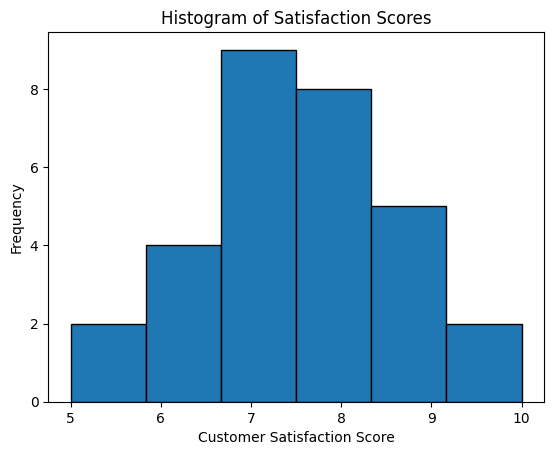

In [14]:
#(B) Histogram Ploting

import matplotlib.pyplot as plt

plt.hist(scores,bins=6,edgecolor='black')
plt.xlabel("Customer Satisfaction Score")
plt.ylabel("Frequency")
plt.title("Histogram of Satisfaction Scores")

plt.show()

### Problem-3

A marketing team wants to understand the relationship between their monthly advertising expenditure (in INR Lakhs) and corresponding sales revenue (in INR Lakhs) over the last 10 months.

| Month | Advertising Spend (X) | Sales Revenue (Y) |
|-------|-----------------------|-------------------|
|     1 |                     5 |                52 |
|     2 |                     7 |                65 |
|     3 |                     6 |                60 |
|     4 |                     8 |                70 |
|     5 |                     5 |                55 |
|     6 |                     9 |                75 |
|     7 |                     7 |                68 |
|     8 |                    10 |                80 |
|     9 |                     6 |                58 |
|    10 |                     8 |                72 |


(a) Calculate the covariance between advertising spend and sales revenue.

(b) Plot Sales Revenue vs Advertising spent.

(c) Calculate the Pearson correlation coefficient between advertising spend and sales revenue.

(d) Interpret the meaning of both the covariance and the correlation coefficient in the context of this data.

(a) Covariance between Advertising Spend and Sales Revenue: 14.9444


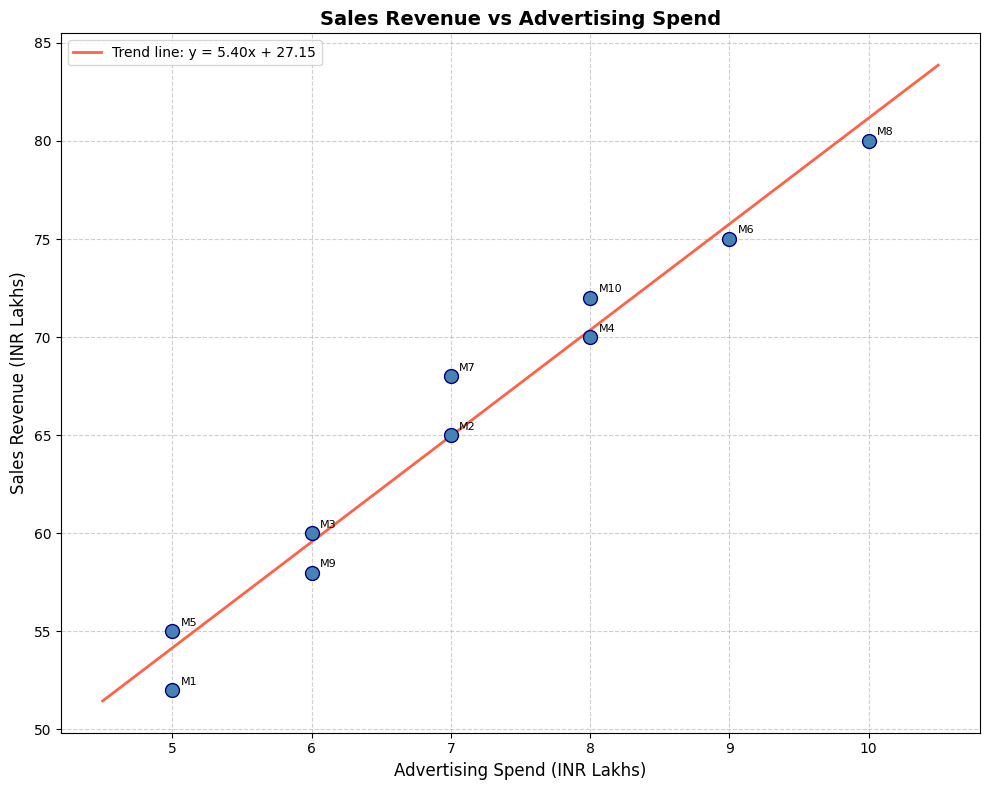

(b) Plot saved as 'sales_vs_advertising.png'

(c) Pearson Correlation Coefficient (r): 0.9852

(d) Interpretation:
-------------------
Covariance (14.9444):
  - A positive covariance indicates that as advertising spend increases,
    sales revenue also tends to increase.
  - However, covariance alone doesn't tell us the strength of the relationship
    since it depends on the units/scale of the variables.

Pearson Correlation Coefficient (0.9852):
  - A value close to +1 confirms a strong positive linear relationship
    between advertising spend and sales revenue.
  - This means ~98.5% of the variation in sales revenue can be explained
    by changes in advertising spend (r² = 0.9706).
  - In business terms: higher advertising investment is strongly associated
    with higher sales revenue over the 10-month period.



In [15]:
# (A) Covariance : Do two variables move together or in opposite direction. 
# This is to check the realtion between two different variables
# Correlation : there is problem with covariance if the two variables have different units.
# We use correlation which is a standardized covariance 

import numpy as np
import matplotlib.pyplot as plt

X = np.array([5, 7, 6, 8, 5, 9, 7, 10, 6, 8])
Y = np.array([52, 65, 60, 70, 55, 75, 68, 80, 58, 72])

# (a) Covariance
# [    X            Y      ]
#[[  Var(X)    Cov(X,Y) ]
# [ Cov(Y,X)   Var(Y)  ]]
cov_matrix = np.cov(X,Y,ddof=1)
covariance = cov_matrix[0,1]
covariance
print(f"(a) Covariance between Advertising Spend and Sales Revenue: {covariance:.4f}")

# (b) Plot Sales Revenue vs Advertising Spend
plt.figure(figsize=(10,8))
plt.scatter(X,Y,color='steelblue',edgecolors='navy',s=100,zorder=5)

m, b = np.polyfit(X,Y,1)

x_line  = np.linspace(X.min()-0.5,X.max()+0.5,100)

plt.plot(x_line,m*x_line+b,color='tomato',linewidth=2,label=f'Trend line: y = {m:.2f}x + {b:.2f}')

for i, (xi, yi) in enumerate(zip(X, Y), start=1):
    plt.annotate(f'M{i}', (xi, yi), textcoords="offset points", xytext=(6, 4), fontsize=8)

plt.title('Sales Revenue vs Advertising Spend', fontsize=14, fontweight='bold')
plt.xlabel('Advertising Spend (INR Lakhs)', fontsize=12)
plt.ylabel('Sales Revenue (INR Lakhs)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('sales_vs_advertising.png', dpi=150)
plt.show()
print("(b) Plot saved as 'sales_vs_advertising.png'")

# (c) Pearson Correlation Coefficient
pearson_r = np.corrcoef(X, Y)[0, 1]
print(f"\n(c) Pearson Correlation Coefficient (r): {pearson_r:.4f}")

# (d) Interpretation
print("""
(d) Interpretation:
-------------------
Covariance ({:.4f}):
  - A positive covariance indicates that as advertising spend increases,
    sales revenue also tends to increase.
  - However, covariance alone doesn't tell us the strength of the relationship
    since it depends on the units/scale of the variables.

Pearson Correlation Coefficient ({:.4f}):
  - A value close to +1 confirms a strong positive linear relationship
    between advertising spend and sales revenue.
  - This means ~{:.1f}% of the variation in sales revenue can be explained
    by changes in advertising spend (r² = {:.4f}).
  - In business terms: higher advertising investment is strongly associated
    with higher sales revenue over the 10-month period.
""".format(covariance, pearson_r, pearson_r * 100, pearson_r**2))


### Problem-4

A traffic department claims that the average daily commute time for residents in a certain city is 45 minutes. A researcher believes this claim is too low and collects data from a random sample of 100 residents. The sample mean commute time is 48 minutes with a standard deviation of 12 minutes.

(a) Formulate the null and alternative hypotheses for this scenario.

(b) Construct a 95% confidence interval for the true average daily commute time.

(c) Based on the confidence interval, what can you conclude about the traffic department's claim?

In [16]:
# (a) Formulate the null and alternative hypotheses for this scenario.
import numpy as np
import scipy.stats as sts

# Given data

u = 45
sample = 100
sam_mean = 48
std = 12
alpha = 0.05
print("-"*20)
print(f"Null hypothesis average daily commute for residents in a certain city is : {u}")
print(f"Alternative hypothesis average daily commute for residents in a certain city is > {u}")
print("This is one tailed(right-tail) test")
print("Because the researcher thinks claim is very low")

# (b) Construct a 95% confidence interval for the true average daily commute time.

print("Step 1","-"*20)
print("Standard Error (SE): How much can our sample mean vary")

std_error = std / np.sqrt(sample)

print("\nStep 2","-"*20)
print("t-critical value")

df = sample-1
t_critical = sts.t.ppf(1-alpha/2,df=df)
print(f"df n - 1 = {sample} - 1 = {df}")
print(f"a / 2 = {alpha} / 2 = {alpha/2}")
print(f"t-critical : {t_critical:.4f}")

print("\nStep 3 Margin of Error","-"*20)
ME = t_critical * std_error
print(f"Margin error: {t_critical:.4f} * {std_error} = {t_critical*std_error:.4f}")

print("\nStep 4 - Confidence interval")
lower = sam_mean - ME
upper = sam_mean + ME

print(f"Confidence interval is between : {lower:.2f} between {upper:.2f} minutes")

# (c) Based on the confidence interval, what can you conclude about the traffic department's claim?

print("-"*40)
print("Conclusion")
if u < lower:
    print(f"\n  Since {u} is BELOW the CI ({lower:.2f}, {upper:.2f})")
    print(f"  {u} falls OUTSIDE the confidence interval")
    print(f"  REJECT null hypothesis")
    print(f"  The claim of {u} mins is NOT supported by data")
    print(f"  True average commute is likely HIGHER than {u} minutes")
else:
    print(f"\n  Since {u} lies INSIDE the CI ({lower:.2f}, {upper:.2f})")
    print(f" FAIL TO REJECT null hypothesis")
    print(f" The claim of {u} mins is supported by data")

--------------------
Null hypothesis average daily commute for residents in a certain city is : 45
Alternative hypothesis average daily commute for residents in a certain city is > 45
This is one tailed(right-tail) test
Because the researcher thinks claim is very low
Step 1 --------------------
Standard Error (SE): How much can our sample mean vary

Step 2 --------------------
t-critical value
df n - 1 = 100 - 1 = 99
a / 2 = 0.05 / 2 = 0.025
t-critical : 1.9842

Step 3 Margin of Error --------------------
Margin error: 1.9842 * 1.2 = 2.3811

Step 4 - Confidence interval
Confidence interval is between : 45.62 between 50.38 minutes
----------------------------------------
Conclusion

  Since 45 is BELOW the CI (45.62, 50.38)
  45 falls OUTSIDE the confidence interval
  REJECT null hypothesis
  The claim of 45 mins is NOT supported by data
  True average commute is likely HIGHER than 45 minutes


### Problem-5

A manufacturing company wants to estimate the average number of units produced per hour by a new machine. They take 36 random observations and find the sample mean to be 150 units with a sample standard deviation of 15 units.

(a) What is the point estimate for the true average number of units produced per hour?

(b) Construct a 99% confidence interval for the true average number of units produced per hour.

(c) If the company wants to be 99% confident that their estimate is within 3 units of the true mean, what sample size would they need (assuming the same standard deviation)?

In [17]:
import math

s_size = 36
s_mean = 150
std_dev = 15
alpha = 0.01
E = 3

# (a) What is the point estimate for the true average number of units produced per hour?
print("="*40)
print("(a) POINT ESTIMATE")
print("="*40)
print(f"\n Point Estimate - Sample Mean = {s_mean} units/hour")

# (b) 99% Confidence Interval

print("="*40)
print("(b) 99% CONFIDENCE INTERVAL")
print("=" * 55)

SE = std_dev / np.sqrt(s_size)
print(f"\n  Step 1 → Standard Error")
print(f"Standard Deviation: {SE}")

print("="*40)
print("Calculating the t-critical value")
print(f"\n  Step 2 → t-critical value")
df = s_size - 1
t_critical = sts.t.ppf(1 - alpha/2, df=df)
print(f"DF = {df}\nalpha: {alpha/2}\nt-critical: {t_critical:.4f}")


ME = t_critical * SE
print(f"\n  Step 3 → Margin of Error")
print(f"           ME = t × SE = {t_critical:.4f} × {SE:.4f} = {ME:.4f}")

print("Confident interval 99%")
lower =  s_mean - ME
upper = s_mean + ME
print(f"\n  Step 4 → Confidence Interval")
print(f" Lower = {s_mean} - {ME:.4f} = {lower:.4f}")
print(f" Upper = {s_mean} + {ME:.4f} = {upper:.4f}")
print(f"\n 99% Confidence Interval : ({lower:.2f}, {upper:.2f}) units/hour")

# (c) Required Sample Size
print("\n" + "=" * 55)
print("(c) REQUIRED SAMPLE SIZE")
print("=" * 55)

z_critical = sts.norm.ppf(1 - alpha/2)

print(f"\n  Why Z and not t?")
print(f" n is unknown so df = n-1 is unknown → use Z")
print(f"\n  Z-critical (99%) = {z_critical:.4f}")
print(f"Desired Margin of Error (E) = {ME} units")
print(f"Standard Deviation (s) = {std_dev} units")

n_required = math.ceil((z_critical * std_dev / E) ** 2)
print(f"\n Formula : n = (Z × s / E)²")
print(f" = ({z_critical:.4f} × {std_dev} / {E})²")
print(f" = ({z_critical * std_dev / E:.4f})²")
print(f" = {(z_critical * std_dev / E)**2:.4f}")
print(f" = {n_required}  (always round UP)")
print(f"\n Required Sample Size : {n_required} observations")

print("\n" + "=" * 55)
print("SUMMARY")
print("=" * 55)
print(f"  (a) Point Estimate          : {s_mean} units/hour")
print(f"  (b) 99% Confidence Interval : ({lower:.2f}, {upper:.2f}) units/hour")
print(f"  (c) Required Sample Size    : {n_required} observations")
print(f"\n  Current n={s_size}  → CI width = ±{ME:.2f} units")
print(f"  Required n={n_required} → CI width = ±{E} units")


(a) POINT ESTIMATE

 Point Estimate - Sample Mean = 150 units/hour
(b) 99% CONFIDENCE INTERVAL

  Step 1 → Standard Error
Standard Deviation: 2.5
Calculating the t-critical value

  Step 2 → t-critical value
DF = 35
alpha: 0.005
t-critical: 2.7238

  Step 3 → Margin of Error
           ME = t × SE = 2.7238 × 2.5000 = 6.8095
Confident interval 99%

  Step 4 → Confidence Interval
 Lower = 150 - 6.8095 = 143.1905
 Upper = 150 + 6.8095 = 156.8095

 99% Confidence Interval : (143.19, 156.81) units/hour

(c) REQUIRED SAMPLE SIZE

  Why Z and not t?
 n is unknown so df = n-1 is unknown → use Z

  Z-critical (99%) = 2.5758
Desired Margin of Error (E) = 6.809513973020228 units
Standard Deviation (s) = 15 units

 Formula : n = (Z × s / E)²
 = (2.5758 × 15 / 3)²
 = (12.8791)²
 = 165.8724
 = 166  (always round UP)

 Required Sample Size : 166 observations

SUMMARY
  (a) Point Estimate          : 150 units/hour
  (b) 99% Confidence Interval : (143.19, 156.81) units/hour
  (c) Required Sample Size  

### Problem-6

A website designer believes that a new website redesign will increase the average time users spend on the site. Before the redesign, the average time spent was 3.5 minutes. After the redesign, a random sample of 50 users showed an average time of 3.8 minutes with a standard deviation of 1.0 minute.

(a) Perform a one-sided hypothesis test at a 0.05 significance level to determine if the redesign significantly increased the average time spent.

(b) State your null and alternative hypotheses, calculate the test statistic, and determine the p-value.

(c) What is your conclusion regarding the website redesign's impact?

In [18]:

p_mean   = 3.5      # Population mean before redesign
n      = 50       # Sample size
x_bar  = 3.8      # Sample mean after redesign
s      = 1.0      # Sample standard deviation
alpha  = 0.05     # Significance level


# (a) & (b) Hypothesis Test
print("=" * 55)
print("(a) & (b) HYPOTHESIS TEST")
print("=" * 55)

# Step 1 - Hypotheses
print(f"\n  Step 1 Hypotheses")
print(f"  H0 : mu = {p_mean} mins  (redesign made no difference)")
print(f"  H1 : mu > {p_mean} mins  (redesign increased time)")
print(f"One-tailed (Right-tailed) test")

# Step 2 - Standard Error
SE = s / np.sqrt(n)
print(f"\n  Step 2 Standard Error")
print(f"  SE = s / √n = {s} / √{n} = {SE:.4f}")

# Step 3 - Test Statistic
t_stat = (x_bar - p_mean) / SE
print(f"\n  Step 3 Test Statistic")
print(f"  t = (x_bar - p_mean) / SE")
print(f"    = ({x_bar} - {p_mean}) / {SE:.4f}")
print(f"    = {x_bar - p_mean} / {SE:.4f}")
print(f"    = {t_stat:.4f}")

# Step 4 - t-critical and p-value
df         = n - 1
t_critical = sts.t.ppf(1 - alpha, df=df)    # one-tailed
p_value    = 1 - sts.t.cdf(t_stat, df=df)   # right-tailed
print(f"\n  Step 4 t-critical and p-value")
print(f"  df         = n - 1 = {n} - 1 = {df}")
print(f"  t-critical = {t_critical:.4f}  (df={df}, alpha={alpha}, one-tail)")
print(f"  p-value    = {p_value:.4f}")

# Step 5 - Decision
print(f"\n  Step 5 Decision")
print(f"  t-stat ({t_stat:.4f}) vs t-critical ({t_critical:.4f})")
print(f"  p-value ({p_value:.4f}) vs alpha ({alpha})")

if p_value < alpha:
    print(f"\n  Since p-value ({p_value:.4f}) < alpha ({alpha})")
    print(f"t-stat ({t_stat:.4f}) > t-critical ({t_critical:.4f})")
    print(f"REJECT null hypothesis")
else:
    print(f"\n  Since p-value ({p_value:.4f}) > alpha ({alpha})")
    print(f"t-stat ({t_stat:.4f}) < t-critical ({t_critical:.4f})")
    print(f"FAIL TO REJECT null hypothesis")


# (c) Conclusion

print("\n" + "=" * 55)
print("(c) CONCLUSION")
print("=" * 55)
if p_value < alpha:
    print(f"\n  The p-value ({p_value:.4f}) is less than alpha ({alpha})")
    print(f"Strong evidence that redesign INCREASED time spent")
    print(f"Average time increased from {p_mean} to {x_bar} minutes")
    print(f"The website redesign had a significant positive impact")
else:
    print(f"\n  The p-value ({p_value:.4f}) is greater than alpha ({alpha})")
    print(f"NOT enough evidence that redesign increased time")
    print(f"FAIL to prove the redesign had a significant impact")

print("\n" + "=" * 55)
print("SUMMARY")
print("=" * 55)
print(f"  H0              : mu = {p_mean} mins")
print(f"  H1              : mu > {p_mean} mins")
print(f"  Standard Error  : {SE:.4f}")
print(f"  Test Statistic  : {t_stat:.4f}")
print(f"  t-critical      : {t_critical:.4f}")
print(f"  p-value         : {p_value:.4f}")
print(f"  Decision        : {'REJECT H0' if p_value < alpha else 'FAIL TO REJECT H0'}")


(a) & (b) HYPOTHESIS TEST

  Step 1 Hypotheses
  H0 : mu = 3.5 mins  (redesign made no difference)
  H1 : mu > 3.5 mins  (redesign increased time)
One-tailed (Right-tailed) test

  Step 2 Standard Error
  SE = s / √n = 1.0 / √50 = 0.1414

  Step 3 Test Statistic
  t = (x_bar - p_mean) / SE
    = (3.8 - 3.5) / 0.1414
    = 0.2999999999999998 / 0.1414
    = 2.1213

  Step 4 t-critical and p-value
  df         = n - 1 = 50 - 1 = 49
  t-critical = 1.6766  (df=49, alpha=0.05, one-tail)
  p-value    = 0.0195

  Step 5 Decision
  t-stat (2.1213) vs t-critical (1.6766)
  p-value (0.0195) vs alpha (0.05)

  Since p-value (0.0195) < alpha (0.05)
t-stat (2.1213) > t-critical (1.6766)
REJECT null hypothesis

(c) CONCLUSION

  The p-value (0.0195) is less than alpha (0.05)
Strong evidence that redesign INCREASED time spent
Average time increased from 3.5 to 3.8 minutes
The website redesign had a significant positive impact

SUMMARY
  H0              : mu = 3.5 mins
  H1              : mu > 3.5 mins

### Problem-7

A company implemented a new training program to improve employee productivity. To assess its effectiveness, 15 employees' productivity scores were recorded before and after the training program. The scores are as follows:

| Employee | Before Training | After Training |
|----------|-----------------|----------------|
|        1 |              65 |             70 |
|        2 |              70 |             72 |
|        3 |              60 |             68 |
|        4 |              75 |             73 |
|        5 |              80 |             85 |
|        6 |              68 |             70 |
|        7 |              72 |             75 |
|        8 |              62 |             65 |
|        9 |              78 |             80 |
|       10 |              70 |             72 |
|       11 |              66 |             69 |
|       12 |              73 |             76 |
|       13 |              64 |             67 |
|       14 |              71 |             74 |
|       15 |              69 |             71 |

(a) State the null and alternative hypotheses to test if the training program significantly improved productivity.

(b) Conduct a paired samples t-test at a 0.05 significance level. Calculate the test statistic and the p-value.

(c) Based on your analysis, did the training program effectively improve employee productivity?

In [19]:
#  Data 
before = np.array([65, 70, 60, 75, 80, 68, 72, 62, 78, 70, 66, 73, 64, 71, 69])
after  = np.array([70, 72, 68, 73, 85, 70, 75, 65, 80, 72, 69, 76, 67, 74, 71])
alpha  = 0.05

#  Step 1 : Differences 
d     = after - before        
d_bar = np.mean(d)            # average improvement
Sd    = np.std(d, ddof=1)     # spread of differences
n     = len(d)                # 15 employees

print(f"Differences (After - Before) : {d}")
print(f"Mean Difference  (md)        : {d_bar:.4f}")
print(f"Std Dev          (Sd)        : {Sd:.4f}")

#  Step 2 : Hypotheses 
print("h0 : mu = 0  → Training made NO difference")
print("h1 : mu > 0  → Training IMPROVED productivity")

#  Step 3 : t-test Calculation 
SE     = Sd / np.sqrt(n)              # how much md can vary
t_stat = d_bar / SE                   # how far md is from 0
df     = n - 1                        # degrees of freedom

print(f"\nStandard Error (SE) : {SE:.4f}")
print(f"t-statistic         : {t_stat:.4f}")

#  Step 4 : p-value & Decision 
t_critical = sts.t.ppf(1 - alpha, df=df)
p_value    = 1 - sts.t.cdf(t_stat, df=df)   # one-tailed (right)

print(f"t-critical          : {t_critical:.4f}")
print(f"p-value             : {p_value:.4f}")

#  Step 5 : Conclusion 
print("\n" + "="*45)
if p_value < alpha:
    print(f"p-value ({p_value:.4f}) < alpha ({alpha})  →  REJECT h0")
    print(f"Training significantly improved productivity ")
    print(f"Average improvement = {d_bar:.2f} points per employee")
    print(f"Employees improved  = {np.sum(d > 0)} out of {n}")
else:
    print(f"p-value ({p_value:.4f}) > alpha ({alpha})  →  FAIL TO REJECT h0")
    print(f"Training did NOT significantly improve productivity ]")

Differences (After - Before) : [ 5  2  8 -2  5  2  3  3  2  2  3  3  3  3  2]
Mean Difference  (md)        : 2.9333
Std Dev          (Sd)        : 2.1202
h0 : mu = 0  → Training made NO difference
h1 : mu > 0  → Training IMPROVED productivity

Standard Error (SE) : 0.5474
t-statistic         : 5.3583
t-critical          : 1.7613
p-value             : 0.0001

p-value (0.0001) < alpha (0.05)  →  REJECT h0
Training significantly improved productivity 
Average improvement = 2.93 points per employee
Employees improved  = 14 out of 15


### Problem-8

A battery manufacturer claims that their new 'ProLife' battery lasts longer than their existing 'Standard' battery. A consumer watchdog organization tests 40 'ProLife' batteries and 50 'Standard' batteries. The results are:

ProLife: Sample mean life = 120 hours, Sample standard deviation = 10 hours

Standard: Sample mean life = 115 hours, Sample standard deviation = 12 hours

(a) State the null and alternative hypotheses for testing the manufacturer's claim.

(b) Perform a t-test for two independent means at a 0.02 significance level.

(c) What is your conclusion regarding the manufacturer's claim about the 'ProLife' battery?

In [20]:
n1, x1_bar, s1 = 40, 120, 10    # ProLife
n2, x2_bar, s2 = 50, 115, 12    # Standard
alpha = 0.02

diff = x1_bar - x2_bar
print(f"Step 1 Difference in Means : {x1_bar} - {x2_bar} = {diff} hours")
# Standard Error
SE = np.sqrt((s1**2 / n1) + (s2**2 / n2))
print(f"Step 2 Standard Error (SE) : {SE:.4f}")
# t-statistic
print(f"Step 3 t-statistic: {t_stat:.4f}")
# Degrees of Freedom
df_num = ((s1**2/n1) + (s2**2/n2))**2
df_den = ((s1**2/n1)**2 / (n1-1)) + ((s2**2/n2)**2 / (n2-1))
df     = df_num / df_den
print(f"Step 4 Degrees of Freedom  : {df:.2f}")

# t-critical and p-value
t_critical = sts.t.ppf(1 - alpha, df=df)      # one-tailed
p_value    = 1 - sts.t.cdf(t_stat, df=df)     # right-tailed
print(f"Step 5 t-critical: {t_critical:.4f}")
print(f"p-value: {p_value:.4f}")

print("\n" + "="*50)
if p_value < alpha:
    print(f"p-value ({p_value:.4f}) < alpha ({alpha})  →  REJECT h0")
    print(f"t-stat  ({t_stat:.4f}) > t-critical ({t_critical:.4f})")
    print(f"\nProLife batteries last significantly longer ")
    print(f"Average difference = {diff} hours (120 vs 115)")
else:
    print(f"p-value ({p_value:.4f}) > alpha ({alpha})  →  FAIL TO REJECT h0")
    print(f"No significant difference between batteries ")


Step 1 Difference in Means : 120 - 115 = 5 hours
Step 2 Standard Error (SE) : 2.3195
Step 3 t-statistic: 5.3583
Step 4 Degrees of Freedom  : 87.84
Step 5 t-critical: 2.0847
p-value: 0.0000

p-value (0.0000) < alpha (0.02)  →  REJECT h0
t-stat  (5.3583) > t-critical (2.0847)

ProLife batteries last significantly longer 
Average difference = 5 hours (120 vs 115)


### Problem-9

A popular restaurant chain claims that the average waiting time for a table on weekends is no more than 20 minutes. A local food critic believes it's longer. They record the waiting times (in minutes) for 30 randomly selected tables on various weekends:

`[22, 25, 18, 30, 28, 20, 23, 26, 19, 32, 21, 24, 27, 29, 20, 25, 23, 17, 31, 26, 22, 28, 20, 24, 27, 29, 21, 23, 25, 26]`

(a) Calculate the sample mean and sample standard deviation of the waiting times.

(b) Conduct a one-sided t-test at a 0.01 significance level to assess the food critic's belief.

(c) State your null and alternative hypotheses, calculate the test statistic, and determine the critical value.

(d) Based on your findings, what can you tell the food critic?

In [21]:
wait_times = np.array([
    22, 25, 18, 30, 28, 20, 23, 26, 19, 32,
    21, 24, 27, 29, 20, 25, 23, 17, 31, 26,
    22, 28, 20, 24, 27, 29, 21, 23, 25, 26
])
mu_0  = 20      # Restaurant's claimed max wait time
alpha = 0.01    # Significance level

x_bar = np.mean(wait_times)
s     = np.std(wait_times, ddof=1)
n     = len(wait_times)

print("=" * 50)
print("(a) SAMPLE STATISTICS")
print("=" * 50)
print(f"  Data Points         : {n} tables")
print(f"  Sample Mean   (x_bar)  : {x_bar:.2f} minutes")
print(f"  Std Deviation (s)   : {s:.2f} minutes")
print(f"  Claimed Mean  (mu_0)  : {mu_0} minutes")
print(f"  Difference          : {x_bar - mu_0:.2f} mins above claim")

print("\n" + "=" * 50)
print("(b) & (c) HYPOTHESIS TEST")
print("=" * 50)

print(f"\n  H0 : mu = {mu_0} Wait time is 20 mins or less")
print(f"  H1 : mu > {mu_0} Wait time is MORE than 20 mins")
print(f"One-tailed (Right-tailed) test")

# Standard Error
SE = s / np.sqrt(n)
print(f"\n  Standard Error (SE)= {s:.2f} / sqrt{n} = {SE:.4f}")

# t-statistic
t_stat = (x_bar - mu_0) / SE
print(f"  t-statistic= ({x_bar:.2f} - {mu_0}) / {SE:.4f} = {t_stat:.4f}")

# t-critical and p-value
df         = n - 1
t_critical = sts.t.ppf(1 - alpha, df=df)
p_value    = 1 - sts.t.cdf(t_stat, df=df)

print(f"  Degrees of Freedom  = {n} - 1 = {df}")
print(f"  t-critical= {t_critical:.4f}  (df={df}, alpha={alpha})")
print(f"  p-value   = {p_value:.7f}")

# Decision
print(f"\n  t-stat ({t_stat:.4f}) vs t-critical ({t_critical:.4f})")
print(f"  p-value ({p_value:.7f}) vs alpha ({alpha})")

print("\n" + "=" * 50)
print("(d) WHAT TO TELL THE FOOD CRITIC")
print("=" * 50)

if p_value < alpha:
    print(f"\n  p-value ({p_value:.7f}) << alpha ({alpha})")
    print(f"  t-stat  ({t_stat:.4f}) >> t-critical ({t_critical:.4f})")
    print(f"\n REJECT h0 ")
    print(f" Restaurant's claim of {mu_0} mins is FALSE")
    print(f" True average wait is significantly HIGHER")
    print(f"\n  Evidence for the critic:")
    print(f" Sample mean = {x_bar:.1f} mins ({x_bar-mu_0:.1f} mins above claim)")
    print(f" Only 0.00007% chance this happened by luck very less")
else:
    print(f"\n  p-value ({p_value:.4f}) > alpha ({alpha})")
    print(f" FAIL TO REJECT H0")
    print(f" Restaurant's claim appears to be valid")
'''
If t-stat > t-critical → REJECT H0
If t-stat < t-critical → FAIL TO REJECT H0

what is t-STATISTICS
Your TEST SCORE
Measures how far your result is from H₀
in units of Standard Error

what is t-critical
The MINIMUM t-score needed to reject H₀
The cutoff line on the number line

what is p-value
The PROBABILITY that your result happened by luck
assuming H₀ is true

Small p-value → Very unlikely to be luck → Real effect
Large p-value → Could easily be luck     → No real effect

p = 0.0000007 → 0.00007% chance it's luck (Problem 9)
p = 0.017     → 1.7%    chance it's luck (Problem 8)
p = 0.019     → 1.9%    chance it's luck (Problem 6)
p = 0.0002    → 0.02%   chance it's luck (Problem 7)
'''


(a) SAMPLE STATISTICS
  Data Points         : 30 tables
  Sample Mean   (x_bar)  : 24.37 minutes
  Std Deviation (s)   : 3.93 minutes
  Claimed Mean  (mu_0)  : 20 minutes
  Difference          : 4.37 mins above claim

(b) & (c) HYPOTHESIS TEST

  H0 : mu = 20 Wait time is 20 mins or less
  H1 : mu > 20 Wait time is MORE than 20 mins
One-tailed (Right-tailed) test

  Standard Error (SE)= 3.93 / sqrt30 = 0.7168
  t-statistic= (24.37 - 20) / 0.7168 = 6.0922
  Degrees of Freedom  = 30 - 1 = 29
  t-critical= 2.4620  (df=29, alpha=0.01)
  p-value   = 0.0000006

  t-stat (6.0922) vs t-critical (2.4620)
  p-value (0.0000006) vs alpha (0.01)

(d) WHAT TO TELL THE FOOD CRITIC

  p-value (0.0000006) << alpha (0.01)
  t-stat  (6.0922) >> t-critical (2.4620)

 REJECT h0 
 Restaurant's claim of 20 mins is FALSE
 True average wait is significantly HIGHER

  Evidence for the critic:
 Sample mean = 24.4 mins (4.4 mins above claim)
 Only 0.00007% chance this happened by luck very less


"\nIf t-stat > t-critical → REJECT H0\nIf t-stat < t-critical → FAIL TO REJECT H0\n\nwhat is t-STATISTICS\nYour TEST SCORE\nMeasures how far your result is from H₀\nin units of Standard Error\n\nwhat is t-critical\nThe MINIMUM t-score needed to reject H₀\nThe cutoff line on the number line\n\nwhat is p-value\nThe PROBABILITY that your result happened by luck\nassuming H₀ is true\n\nSmall p-value → Very unlikely to be luck → Real effect\nLarge p-value → Could easily be luck     → No real effect\n\np = 0.0000007 → 0.00007% chance it's luck (Problem 9)\np = 0.017     → 1.7%    chance it's luck (Problem 8)\np = 0.019     → 1.9%    chance it's luck (Problem 6)\np = 0.0002    → 0.02%   chance it's luck (Problem 7)\n"

### Problem-10

A software company is launching a new application and offers three different subscription tiers (Basic, Premium, Elite), each with varying features. Before the full launch, they conduct a pilot study to see if there's an association between a customer's age group and their preferred subscription tier. They surveyed 300 randomly selected potential customers and recorded their age group and preferred tier:

| Age Group   | Basic | Premium | Elite | Total |
|-------------|-------|---------|-------|-------|
| 18-29 years |    45 |      60 | 15    | 120   |
| 30-49 years |    30 |      50 | 20    | 100   |
|   50+ years |    25 |      40 | 15    | 80    |
|       Total |   100 |     150 | 50    | 300   |


(a) State the null and alternative hypotheses for the test of independence in this context.

(b) Calculate the expected frequencies for each cell in the table, assuming the null hypothesis is true. Show your calculations clearly.

(c) Calculate the chi-square test statistic.

(d) Using a significance level of α=0.05, determine the critical value for this test.

(e) What is your conclusion? Is there a significant association between a customer's age group and their preferred subscription tier? Justify your answer based on your calculated chi-square statistic and the critical value.

In [22]:


#  Data 
#  Basic  Premium  Elite
observed = np.array([
    [45, 60, 15],    # 18-29 years
    [30, 50, 20],    # 30-49 years
    [25, 40, 15],    # 50+  years
])

alpha      = 0.05    # Significance level
row_labels = ['18-29 yrs', '30-49 yrs', '50+ yrs']
col_labels = ['Basic', 'Premium', 'Elite']

#  Row totals, Column totals, Grand total 
row_totals   = observed.sum(axis=1)    # sum across column [120, 100, 80]
col_totals   = observed.sum(axis=0)    # sum across rows   [100, 150, 50]
grand_total  = observed.sum()          # 300

# 
# (a) Hypotheses
# 
print("=" * 50)
print("(a) HYPOTHESES")
print("=" * 50)
print(f"\n  H0 : No association between age group and subscription tier")
print(f" Age group and tier preference are INDEPENDENT")
print(f"\n  H1 : There IS an association between age group and tier")
print(f" Age group and tier preference are NOT independent")
print(f"\n Chi-Square Test of Independence")

# 
# (b) Expected Frequencies
# 
print("\n" + "=" * 50)
print("(b) EXPECTED FREQUENCIES")
print("=" * 50)
print(f"\n  Formula : E = (Row Total × Col Total) / Grand Total")
print(f"  Grand Total = {grand_total}\n")

# Calculate expected frequencies
expected = np.outer(row_totals, col_totals) / grand_total

# Show each calculation clearly
for i in range(3):
    for j in range(3):
        E = expected[i][j]
        print(f"  E[{row_labels[i]}][{col_labels[j]}]"
              f" = ({row_totals[i]} × {col_totals[j]}) / {grand_total}"
              f" = {E:.2f}")
    print()

# Print expected table
print(f"  Expected Frequency Table:")
print(f"  {'Age Group':<12} {'Basic':>8} {'Premium':>9} {'Elite':>7}")
print(f"  {'-'*40}")
for i in range(3):
    print(f"  {row_labels[i]:<12} {expected[i][0]:>8.2f} {expected[i][1]:>9.2f} {expected[i][2]:>7.2f}")

# 
# (c) Chi-Square Statistic
# 
print("\n" + "=" * 50)
print("(c) CHI-SQUARE STATISTIC")
print("=" * 50)
print(f"\n  Formula : chi2 = sum of (O - E)² / E")
print(f"  O = Observed frequency")
print(f"  E = Expected frequency\n")

chi2_stat = 0
for i in range(3):
    for j in range(3):
        O     = observed[i][j]
        E     = expected[i][j]
        value = (O - E)**2 / E
        chi2_stat += value
        print(f"  [{row_labels[i]}][{col_labels[j]}]"
              f" = ({O} - {E:.2f})² / {E:.2f}"
              f" = {(O-E)**2:.4f} / {E:.2f}"
              f" = {value:.4f}")
    print()

print(f"  chi2_stat = sum of all above = {chi2_stat:.4f}")

# 
# (d) Critical Value
# 
print("\n" + "=" * 50)
print("(d) CRITICAL VALUE")
print("=" * 50)

rows = observed.shape[0]    # 3 age groups
cols = observed.shape[1]    # 3 tiers
df   = (rows - 1) * (cols - 1)

chi2_critical = sts.chi2.ppf(1 - alpha, df=df)
p_value       = 1 - sts.chi2.cdf(chi2_stat, df=df)

print(f"\n  Degrees of Freedom = (rows-1) × (cols-1)")
print(f"                     = ({rows}-1) × ({cols}-1)")
print(f"                     = {rows-1} × {cols-1} = {df}")
print(f"\n  alpha              = {alpha}")
print(f"  chi2_critical      = {chi2_critical:.4f}  (df={df}, alpha={alpha})")
print(f"  p-value            = {p_value:.4f}")

# 
# (e) Conclusion
# 
print("\n" + "=" * 50)
print("(e) CONCLUSION")
print("=" * 50)

print(f"\n  chi2_stat     ({chi2_stat:.4f}) vs chi2_critical ({chi2_critical:.4f})")
print(f"  p-value       ({p_value:.4f})  vs alpha         ({alpha})")

if chi2_stat > chi2_critical:
    print(f"\n  chi2 ({chi2_stat:.4f}) > critical ({chi2_critical:.4f})")
    print(f"  p-value ({p_value:.4f}) < alpha ({alpha})")
    print(f"\n REJECT H0 ")
    print(f" There IS a significant association between")
    print(f"     age group and subscription tier preference")
    print(f" Age group DOES influence which tier customers choose")
else:
    print(f"\n  chi2 ({chi2_stat:.4f}) < critical ({chi2_critical:.4f})")
    print(f"  p-value ({p_value:.4f}) > alpha ({alpha})")
    print(f"\n FAIL TO REJECT H0 ")
    print(f" No significant association between")
    print(f"     age group and subscription tier preference")

#  Summary 
print("\n" + "=" * 50)
print("SUMMARY")
print("=" * 50)
print(f"  Observed Data     : 3×3 table (300 customers)")
print(f"  Degrees of Freedom: {df}")
print(f"  chi2_statistic    : {chi2_stat:.4f}")
print(f"  chi2_critical     : {chi2_critical:.4f}")
print(f"  p-value           : {p_value:.4f}")
print(f"  Decision          : {'REJECT H0 ' if chi2_stat > chi2_critical else 'FAIL TO REJECT H0 '}")

(a) HYPOTHESES

  H0 : No association between age group and subscription tier
 Age group and tier preference are INDEPENDENT

  H1 : There IS an association between age group and tier
 Age group and tier preference are NOT independent

 Chi-Square Test of Independence

(b) EXPECTED FREQUENCIES

  Formula : E = (Row Total × Col Total) / Grand Total
  Grand Total = 300

  E[18-29 yrs][Basic] = (120 × 100) / 300 = 40.00
  E[18-29 yrs][Premium] = (120 × 150) / 300 = 60.00
  E[18-29 yrs][Elite] = (120 × 50) / 300 = 20.00

  E[30-49 yrs][Basic] = (100 × 100) / 300 = 33.33
  E[30-49 yrs][Premium] = (100 × 150) / 300 = 50.00
  E[30-49 yrs][Elite] = (100 × 50) / 300 = 16.67

  E[50+ yrs][Basic] = (80 × 100) / 300 = 26.67
  E[50+ yrs][Premium] = (80 × 150) / 300 = 40.00
  E[50+ yrs][Elite] = (80 × 50) / 300 = 13.33

  Expected Frequency Table:
  Age Group       Basic   Premium   Elite
  ----------------------------------------
  18-29 yrs       40.00     60.00   20.00
  30-49 yrs       33.33    

### Bonus Problem

An e-commerce company is testing two different designs for its product pages (Design A and Design B) to see if one leads to significantly higher conversion rates (percentage of visitors who make a purchase). They randomly assigned 50,000 website visitors to see Design A and another 50,000 visitors to see Design B over a two-week period. At the end of the period, they collected data on the conversion rates. Due to data collection specifics, they have daily average conversion rates for 30 randomly selected days for each design, rather than individual visitor data.

Here are the summary statistics for the daily average conversion rates (in percentage points):

* Design A (Sample 1):

    - Number of days ($n_A$) = 30
    - Mean Daily Conversion Rate ($\bar{x}_A$) = 2.85%
    - Sample Standard Deviation ($s_A$) = 0.45%

* Design B (Sample 2):

    - Number of days ($n_B$) = 30
    - Mean Daily Conversion Rate ($\bar{x}_B$) = 3.05%
    - Sample Standard Deviation ($s_B$) = 0.60%

The company is concerned that the variability in conversion rates might differ between the two designs due to different aesthetic elements or backend processes.

(a) State the null and alternative hypotheses to test if there is a significant difference in the average daily conversion rates between Design A and Design B. (Consider a two-tailed test, as they are looking for any significant difference).

(b) Before performing the t-test, you need to decide whether to assume equal or unequal population variances. For the purpose of this problem, assume that a prior test suggests equal population variances.

(c) Calculate the appropriate test statistic (t-value) for comparing the two independent means, assuming equal population variances. Show all steps of your calculation.

(d) Determine the degrees of freedom for this test. 

(e) Using a significance level of α=0.05, determine the critical value(s) for your test.

(f) Based on your calculated test statistic and the critical value(s), what is your conclusion? Is there a statistically significant difference in the average daily conversion rates between Design A and Design B?

(g) Construct a 95% confidence interval for the difference between the true mean daily conversion rates $(μ_B - μ_A)$. Interpret this interval in the context of the problem.

(h) Show all the steps when a prior test suggests unequal population variances.